# Phase 9 - Community structure on social graphs

The professor's question: does a social graph's **natural community structure** explain when augmentation works?

Louvain community detection on the **10 smallest social graphs** (by nodes) - on the original graph and on its three role graphs (`psi`, `degree`, `centrality`, K=10). The link-prediction results are the existing ones: nothing retrained, no rule changed.

**Community strength** = Louvain modularity Q: 0 = no communities, 1 = very strong communities.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from virgo import config as cfg
from virgo import frozen_rules as fr

# Same table style as notebooks 6-7: fixed layout + wrapped headers, so a wide table never scrolls out of the output area.
STYLE = [
    {"selector": "table", "props": [("width", "100%"), ("table-layout", "fixed"), ("font-size", "11px")]},
    {"selector": "th", "props": [("white-space", "normal"), ("word-wrap", "break-word"), ("text-align", "center"), ("padding", "4px")]},
    {"selector": "td", "props": [("white-space", "normal"), ("word-wrap", "break-word"), ("text-align", "center"), ("padding", "4px")]},
]
show = lambda df, digits=2: display(df.style.format(precision=digits).set_table_styles(STYLE).hide(axis="index"))
signals = lambda s: s.str.replace("|", " / ", regex=False)

PANEL = cfg.COMMUNITY_SOCIAL_PILOT
cmp = pd.read_csv("results/community_compare.csv").set_index("dataset").loc[PANEL].reset_index()
summary = pd.read_csv("results/community_summary.csv")
summary = summary[summary.dataset.isin(PANEL)]
corr = pd.read_csv("results/community_correlations.csv")
graphs = pd.read_csv("results/community_graphs.csv")
graphs = graphs[graphs.dataset.isin(PANEL)]
rho = lambda x, y: corr[(corr.x == x) & (corr.y == y)].value.iloc[0]

# Chart tokens: light surface, solid hairline grid, ink-coloured text; two colour-blind-safe categorical slots.
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VERDICT = {"augment": BLUE, "keep original": ORANGE}
SEQ = LinearSegmentedColormap.from_list("blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
                     "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
                     "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
                     "grid.linestyle": "-", "axes.axisbelow": True, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
                     "figure.dpi": 100})


def dots(ax, d, x, y, colour_by):
    '''One dot per graph, coloured by keep / augment, with a surface ring so overlapping dots stay legible.'''
    for level, colour in VERDICT.items():
        s = d[d[colour_by] == level]
        ax.scatter(s[x], s[y], s=60, color=colour, edgecolor=SURFACE, linewidth=1.5, zorder=3, label=level)


def label_points(ax, d, x, y):
    '''Graph names beside the dots: first of four spots that stays inside the axes and hits no label, legend or dot.
    Call after tight_layout() and legend(), so the coordinates it checks are final.'''
    r = ax.figure.canvas.get_renderer()
    pts = [tuple(ax.transData.transform((a, b))) for a, b in zip(d[x], d[y])]
    box = ax.bbox
    placed = [ax.get_legend().get_window_extent(r)] if ax.get_legend() else []
    for (px, py), name in zip(pts, d["dataset"]):
        others = [p for p in pts if p != (px, py)]
        first = None
        for dx, dy, ha, va in [(6, 3, "left", "bottom"), (6, -3, "left", "top"),
                               (-6, 3, "right", "bottom"), (-6, -3, "right", "top")]:
            t = ax.annotate(name, ax.transData.inverted().transform((px, py)), xytext=(dx, dy),
                            textcoords="offset points", ha=ha, va=va, fontsize=7.5, color=INK2)
            bb = t.get_window_extent(r)
            hit = not (box.x0 <= bb.x0 and bb.x1 <= box.x1 and box.y0 <= bb.y0 and bb.y1 <= box.y1) or \
                  any(bb.overlaps(b) for b in placed) or \
                  any(bb.x0 - 4 <= ox <= bb.x1 + 4 and bb.y0 - 4 <= oy <= bb.y1 + 4 for ox, oy in others)
            if not hit:
                placed.append(bb)
                break
            first = first or (dx, dy, ha, va)
            t.remove()
        else:
            dx, dy, ha, va = first
            t = ax.annotate(name, ax.transData.inverted().transform((px, py)), xytext=(dx, dy),
                            textcoords="offset points", ha=ha, va=va, fontsize=7.5, color=INK2)
            placed.append(t.get_window_extent(r))


def heatmap(ax, mat, title):
    '''Graphs x columns, one sequential hue (0 = light, 1 = dark), each value printed in ink or white.'''
    ax.imshow(mat.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(mat.shape[1]), mat.columns)
    ax.set_yticks(range(mat.shape[0]), mat.index)
    ax.grid(False)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.55 else INK)
    ax.set_title(title)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)


print(f"graphs ({len(PANEL)}, smallest by nodes): {PANEL}")
print("Louvain: resolution 1, seeds 42-44 (averaged) | link prediction: existing GraphSAGE results, K=10")

graphs (10, smallest by nodes): ['spanish_highschool_6', 'reed98', 'twitch_ptbr', 'amherst41', 'twitch_ru', 'twitch_es', 'johnshopkins55', 'blogcatalog', 'twitch_fr', 'twitch_engb']
Louvain: resolution 1, seeds 42-44 (averaged) | link prediction: existing GraphSAGE results, K=10


## 1 · The answers

The professor's three questions, and what the 10 graphs show. Each one is detailed in §3-§5.

In [2]:
aug, keep = cmp[cmp.official_verdict == "augment"], cmp[cmp.official_verdict == "keep original"]
lowh = cmp[cmp.stage1_call == "augment"]                     # rule 1 fired = low homophily (all social graphs are low-clustering)
role_hub = aug[["hub_cross_psi", "hub_cross_degree", "hub_cross_centrality"]]
chance = summary[(summary.variant == "original") & summary.dataset.isin(aug.dataset)].chance_cross
show(pd.DataFrame([
    {"professor's question": "Low homophily + low clustering = weak communities, where augmentation helps?",
     "answer": "Partly",
     "what we found": f"Low homophily: yes - the {len(lowh)} low-homophily graphs all have weak communities "
                      f"(Q {lowh.orig_modularity.min():.2f}-{lowh.orig_modularity.max():.2f}) and augmentation helps on "
                      f"{int((lowh.official_verdict == 'augment').sum())}/{len(lowh)}. Low clustering: no - clustering does not "
                      f"follow community strength (ρ {rho('orig_modularity', 'avg_clustering'):+.2f})."},
    {"professor's question": "Strong communities (or high clustering) = keep the original graph?",
     "answer": "Yes for communities - in direction; no for clustering",
     "what we found": f"The only keep graph ({', '.join(keep.dataset)}, Q {keep.orig_modularity.max():.2f}) has by far the "
                      f"strongest communities (all others ≤ {aug.orig_modularity.max():.2f}). Weaker communities, bigger "
                      f"augmentation gain (ρ {rho('orig_modularity', 'official_gap'):+.2f}). One keep graph only: a direction, not proof."},
    {"professor's question": "When augmentation helps, is centrality useful because it links important nodes across (or within) communities?",
     "answer": "No",
     "what we found": f"Role edges ignore communities: {role_hub.min().min():.0%}-{role_hub.max().max():.0%} of hub edges cross "
                      f"them, close to random ({chance.min():.0%}-{chance.max():.0%}). Centrality stays inside communities a bit "
                      f"more than psi/degree - where it wins and where it loses alike."},
]))

professor's question,answer,what we found
"Low homophily + low clustering = weak communities, where augmentation helps?",Partly,Low homophily: yes - the 8 low-homophily graphs all have weak communities (Q 0.29-0.45) and augmentation helps on 8/8. Low clustering: no - clustering does not follow community strength (ρ -0.03).
Strong communities (or high clustering) = keep the original graph?,Yes for communities - in direction; no for clustering,"The only keep graph (spanish_highschool_6, Q 0.71) has by far the strongest communities (all others ≤ 0.45). Weaker communities, bigger augmentation gain (ρ -0.54). One keep graph only: a direction, not proof."
"When augmentation helps, is centrality useful because it links important nodes across (or within) communities?",No,"Role edges ignore communities: 63%-87% of hub edges cross them, close to random (77%-90%). Centrality stays inside communities a bit more than psi/degree - where it wins and where it loses alike."


## 2 · Community detection, per graph

Louvain on the **original** graph, next to the stage-1 call and the existing link-prediction result.

graph,nodes,edges,communities found,community strength (Q),stage 1 says,link prediction shows,winning signal
spanish_highschool_6,534,9527,4,0.71,keep original,keep original,original
reed98,962,18812,6,0.32,augment,augment,centrality
twitch_ptbr,1912,31299,8,0.29,augment,augment,degree / psi
amherst41,2235,90954,6,0.44,augment,augment,centrality / degree / psi
twitch_ru,4385,37304,11,0.34,augment,augment,degree / psi
twitch_es,4648,59382,10,0.40,augment,augment,degree / psi
johnshopkins55,5180,186586,19,0.45,augment,augment,centrality
blogcatalog,5196,171743,9,0.37,keep original,augment,centrality / degree / psi
twitch_fr,6549,112666,8,0.34,augment,augment,degree / psi
twitch_engb,7126,35324,20,0.45,augment,augment,degree


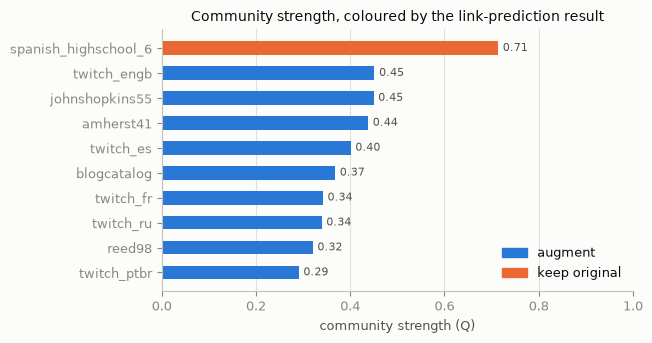

In [3]:
t = cmp[["dataset", "nodes", "edges", "orig_communities", "orig_modularity", "stage1_call", "official_verdict", "official_winners"]].copy()
t["nodes"], t["edges"], t["orig_communities"] = t.nodes.astype(int), t.edges.astype(int), t.orig_communities.round().astype(int)
t["official_winners"] = signals(t.official_winners)
t.columns = ["graph", "nodes", "edges", "communities found", "community strength (Q)", "stage 1 says",
             "link prediction shows", "winning signal"]
show(t)

d = cmp.sort_values("orig_modularity")
fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.barh(d.dataset, d.orig_modularity, height=0.55, color=[VERDICT[v] for v in d.official_verdict])
for yy, v in enumerate(d.orig_modularity):
    ax.text(v + 0.01, yy, f"{v:.2f}", va="center", fontsize=8, color=INK2)
ax.set(xlim=(0, 1), xlabel="community strength (Q)", title="Community strength, coloured by the link-prediction result")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=l) for l, c in VERDICT.items()], loc="lower right")
plt.tight_layout()
plt.show()

**Only one graph has strong communities - and it is the only one where the original graph should be kept.**

## 3 · Q1 - low homophily + low clustering = weak communities?

Colour = what stage 1 says. Grey lines = the frozen cuts (rule 1 on homophily; the clustering exception).

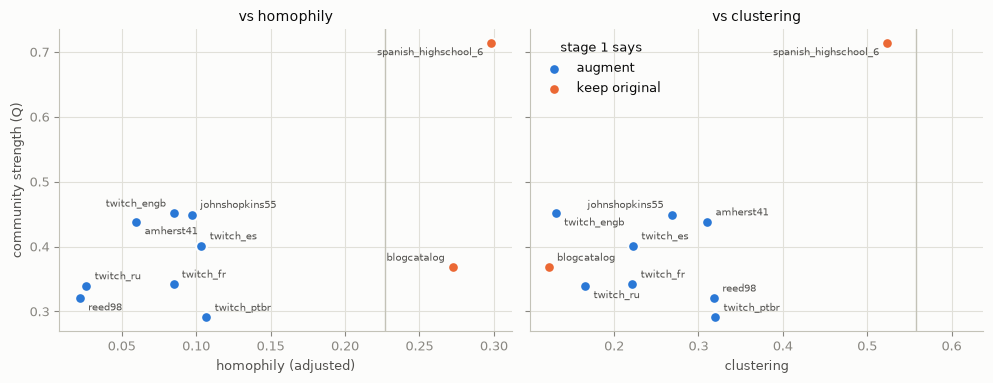

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9), sharey=True)
dots(axes[0], cmp, "homophily_adjusted", "orig_modularity", "stage1_call")
axes[0].set(xlabel="homophily (adjusted)", ylabel="community strength (Q)", title="vs homophily")
axes[0].axvline(fr.FROZEN_RULES[0].point, color=AXIS, linewidth=1)
dots(axes[1], cmp, "avg_clustering", "orig_modularity", "stage1_call")
axes[1].set(xlabel="clustering", title="vs clustering")
axes[1].axvline(fr.FROZEN_EXCEPTION.point, color=AXIS, linewidth=1)
axes[1].set_xlim(right=max(cmp.avg_clustering.max(), fr.FROZEN_EXCEPTION.point) + 0.08)
axes[1].legend(title="stage 1 says", loc="upper left")
plt.tight_layout()
label_points(axes[0], cmp, "homophily_adjusted", "orig_modularity")
label_points(axes[1], cmp, "avg_clustering", "orig_modularity")
plt.show()

**Partly.** The low-homophily graphs all have weak communities, and augmentation helps on every one of them. Clustering tells nothing about communities - and on social graphs the clustering exception never fires (every graph sits left of its cut).

## 4 · Q2 - strong communities = keep the original?

Gain = best augmented AUC − original AUC (existing results). Above 0 = augmentation helps.

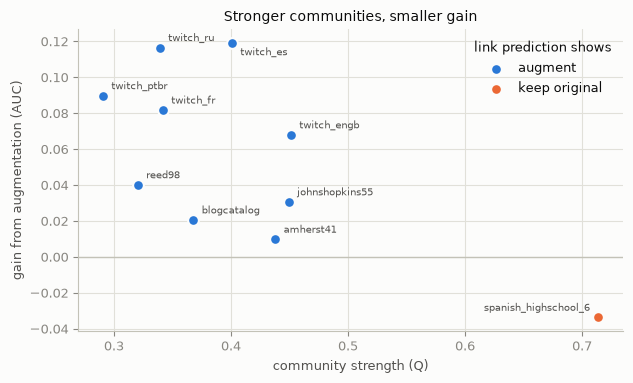

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.9))
dots(ax, cmp, "orig_modularity", "official_gap", "official_verdict")
ax.axhline(0, color=AXIS, linewidth=1)
ax.set(xlabel="community strength (Q)", ylabel="gain from augmentation (AUC)", title="Stronger communities, smaller gain")
ax.legend(title="link prediction shows", loc="upper right")
plt.tight_layout()
label_points(ax, cmp, "orig_modularity", "official_gap")
plt.show()

**Yes, in direction.** The weaker the communities, the more augmentation gains; the strongest-community graph is the one that should stay as it is. `blogcatalog` is the one graph stage 1 gets wrong (homophily says keep, augmentation helps) - its communities are weak, so community strength gets it right.

_Caveat: only one keep graph among these 10. The next 5 graphs add two more keep cases (`lastfm_asia`, `deezer_europe`) - needed to make this a real test._

## 5 · Q3 - does centrality link important nodes across communities?

Important node = top 10% most central. Each cell = share of their edges that **cross** between communities. `original` = the real edges; `random` = what random edges would do.

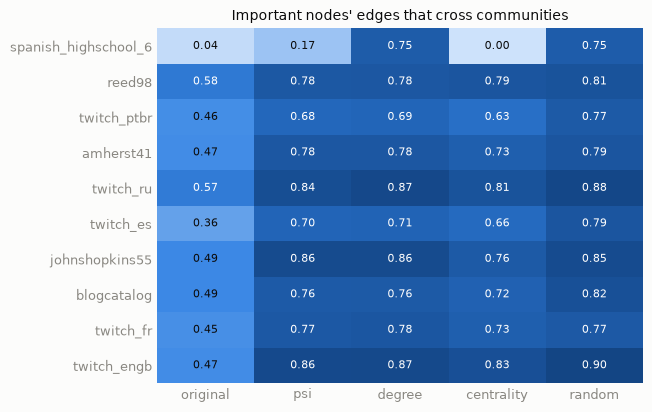

graph,centrality wins?,winning signal,crossing: centrality,crossing: psi,crossing: degree
reed98,yes,centrality,0.79,0.78,0.78
twitch_ptbr,no,degree / psi,0.63,0.68,0.69
amherst41,yes,centrality / degree / psi,0.73,0.78,0.78
twitch_ru,no,degree / psi,0.81,0.84,0.87
twitch_es,no,degree / psi,0.66,0.70,0.71
johnshopkins55,yes,centrality,0.76,0.86,0.86
blogcatalog,yes,centrality / degree / psi,0.72,0.76,0.76
twitch_fr,no,degree / psi,0.73,0.77,0.78
twitch_engb,no,degree,0.83,0.86,0.87


In [6]:
hub = cmp.set_index("dataset")[[f"hub_cross_{v}" for v in cfg.COMMUNITY_VARIANTS]]
hub.columns = cfg.COMMUNITY_VARIANTS
hub["random"] = summary[summary.variant == "original"].set_index("dataset").loc[hub.index, "chance_cross"]
fig, ax = plt.subplots(figsize=(6.6, 4.2))
heatmap(ax, hub, "Important nodes' edges that cross communities")
plt.tight_layout()
plt.show()

w = cmp[cmp.official_verdict == "augment"][["dataset", "official_winners", "hub_cross_centrality", "hub_cross_psi", "hub_cross_degree"]].copy()
w.insert(1, "centrality wins?", w.official_winners.str.contains("centrality").map({True: "yes", False: "no"}))
w["official_winners"] = signals(w.official_winners)
w.columns = ["graph", "centrality wins?", "winning signal", "crossing: centrality", "crossing: psi", "crossing: degree"]
show(w)

**No.** All three role graphs cross communities almost like random edges. Centrality's edges stay inside communities a little more than psi's and degree's (8 of 9 graphs) - but that is equally true where centrality wins (the Facebook graphs, `blogcatalog`) and where it loses (all Twitch graphs). Communities do not explain when centrality wins.

_Hint, not tested: centrality wins where hubs hold fewer of the edges (Facebook graphs) and loses where hubs dominate (Twitch)._

## 6 · Why - augmentation throws the communities away

How much of the original communities each role graph keeps (NMI: 0 = nothing, 1 = identical).

In [7]:
k = cmp[["dataset", "orig_modularity"] + [f"nmi_vs_original_{v}" for v in ["psi", "degree", "centrality"]]].copy()
k.columns = ["graph", "community strength (Q)", "kept by psi graph", "kept by degree graph", "kept by centrality graph"]
show(k)

graph,community strength (Q),kept by psi graph,kept by degree graph,kept by centrality graph
spanish_highschool_6,0.71,0.18,0.04,0.28
reed98,0.32,0.09,0.08,0.11
twitch_ptbr,0.29,0.05,0.04,0.06
amherst41,0.44,0.08,0.07,0.11
twitch_ru,0.34,0.04,0.03,0.05
twitch_es,0.40,0.04,0.03,0.04
johnshopkins55,0.45,0.07,0.07,0.10
blogcatalog,0.37,0.04,0.04,0.06
twitch_fr,0.34,0.02,0.02,0.03
twitch_engb,0.45,0.04,0.03,0.05


**Role graphs keep almost none of the communities (at most 0.28).** Replacing the real edges with them costs little when communities are weak - and most when they are strong. That is the mechanism behind Q2.

## 7 · What this means for the paper

- **Stage 1 gets a label-free explanation:** augment where communities are weak, keep the original where they are strong.
- Stage 1 (homophily) is right on 9 of 10 graphs; on the 10th (`blogcatalog`) community strength sides with the result.
- **Clustering adds nothing** on social graphs.
- **Stage 2 (centrality) is not explained by communities.**
- Next: the 5 remaining graphs, to turn the Q2 direction into a test.

## Appendix · statistics and checks

The seven comparisons fixed before the run (`docs/paper_log.md`, 2026-10-01). Spearman ρ; at n = 10, |ρ| ≥ 0.65 is p < 0.05. Descriptive only - no threshold is read from them.

In [8]:
show(corr, digits=3)
print("role graphs rebuilt vs the study's recorded hashes:", dict(graphs.hash_status.value_counts()))

hypothesis,statistic,x,y,subset,n,value,p,expected,direction_holds
H1,spearman,orig_modularity,homophily_adjusted,all,10,0.370,0.293,+,True
H1,spearman,orig_modularity,avg_clustering,all,10,-0.030,0.934,+,False
H2,spearman,orig_modularity,official_gap,all,10,-0.539,0.108,-,True
H2,spearman,orig_modularity,nonhybrid_gap,all,10,-0.539,0.108,-,True
H3,spearman,hub_cross_centrality,centrality_advantage,non-hybrid verdict augments,9,-0.259,0.500,+,False
H2,median keep - median augment,orig_modularity,nonhybrid_verdict,all,1 keep / 9 augment,0.346,0.200,+,True
H2,median keep - median augment,orig_modularity,official_verdict,all,1 keep / 9 augment,0.346,0.200,+,True


role graphs rebuilt vs the study's recorded hashes: {'NO_REFERENCE': 33, 'EXACT': 7}
